### IMPORTING LIBRARIES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split,RepeatedStratifiedKFold, cross_validate,GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,roc_auc_score,confusion_matrix,classification_report,ConfusionMatrixDisplay,RocCurveDisplay

### LOAD DATASET

In [2]:
values = pd.read_csv("../data/raw/values.csv")
values.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


In [3]:
labels = pd.read_csv("../data/raw/labels.csv")
labels.head()

,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0


#### VALUES DATASET

In [4]:
values.shape

(180, 14)

In [5]:
values.columns.to_list()

['patient_id',
 'slope_of_peak_exercise_st_segment',
 'thal',
 'resting_blood_pressure',
 'chest_pain_type',
 'num_major_vessels',
 'fasting_blood_sugar_gt_120_mg_per_dl',
 'resting_ekg_results',
 'serum_cholesterol_mg_per_dl',
 'oldpeak_eq_st_depression',
 'sex',
 'age',
 'max_heart_rate_achieved',
 'exercise_induced_angina']

In [6]:
values.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


In [7]:
values.tail()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0
179,2nx10r,1,normal,160,3,1,0,0,201,0.0,0,54,163,0


In [8]:
values.sample(10)

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
130,0zldrz,1,reversible_defect,94,3,1,0,0,227,0.0,1,51,154,1
48,1aeaff,2,reversible_defect,120,2,1,0,2,281,1.4,1,62,103,0
110,0g192k,2,reversible_defect,128,4,1,0,0,263,0.2,1,64,105,1
127,w1wgrq,2,reversible_defect,120,3,0,0,2,258,0.4,1,54,147,0
52,r7y4i1,1,reversible_defect,130,4,3,1,2,330,1.8,1,63,132,1
17,237mql,1,reversible_defect,130,4,1,0,0,253,1.4,1,60,144,1
51,ejo7p3,1,normal,130,3,1,0,0,315,1.9,1,43,162,0
22,jhdvtb,1,normal,106,4,2,0,0,223,0.3,0,67,142,0
26,zzmfh7,1,normal,128,4,1,0,2,303,0.0,0,57,159,0
46,6219kl,2,normal,125,3,0,1,2,245,2.4,1,51,166,0


In [9]:
values.dtypes

patient_id                               object
slope_of_peak_exercise_st_segment         int64
thal                                     object
resting_blood_pressure                    int64
chest_pain_type                           int64
num_major_vessels                         int64
fasting_blood_sugar_gt_120_mg_per_dl      int64
resting_ekg_results                       int64
serum_cholesterol_mg_per_dl               int64
oldpeak_eq_st_depression                float64
sex                                       int64
age                                       int64
max_heart_rate_achieved                   int64
exercise_induced_angina                   int64
dtype: object

In [10]:
values.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
dtype: int64

In [11]:
values.duplicated().sum()

np.int64(0)

**Findings:**
- The `values` dataset has 180 rows and 14 columns (13 features + `patient_id`).
- No missing values and no duplicate rows — the raw feature data is clean and needs no imputation or de-duplication.


#### LABELS DATASET

In [12]:
labels.shape

(180, 2)

In [13]:
labels.columns.to_list()

['patient_id', 'heart_disease_present']

In [14]:
labels.head()

,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0


In [15]:
labels.dtypes

patient_id               object
heart_disease_present     int64
dtype: object

In [16]:
labels.isnull().sum()

patient_id               0
heart_disease_present    0
dtype: int64

In [17]:
labels.duplicated().sum()

np.int64(0)

**Findings:**
- The `labels` dataset has 180 rows with `patient_id` and the target `heart_disease_present`.
- No missing values and no duplicate rows.


#### ID CHECK

In [18]:
print("\nUnique patient ID's in values: ")
print(values["patient_id"].nunique())
print("\nUnique patient ID's in labels:")
print(labels["patient_id"].nunique())


Unique patient ID's in values: 
180

Unique patient ID's in labels:
180


In [19]:
print("\nID's present in values but missing in labels:")
print(set(values["patient_id"])-set(labels["patient_id"]))

print("\nID's present in labels but missing in values:")
print(set(labels["patient_id"])-set(values["patient_id"]))


ID's present in values but missing in labels:
set()

ID's present in labels but missing in values:
set()


**Findings:**
- Both datasets contain exactly 180 unique patient IDs, and the ID sets match perfectly (no IDs present in one file but missing from the other).
- This confirms a clean, lossless one-to-one merge is possible on `patient_id`.


### MERGE DATASETS

In [20]:
df = pd.merge(values,labels,on="patient_id",how="inner")
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [21]:
df.shape

(180, 15)

In [22]:
df.columns.to_list()

['patient_id',
 'slope_of_peak_exercise_st_segment',
 'thal',
 'resting_blood_pressure',
 'chest_pain_type',
 'num_major_vessels',
 'fasting_blood_sugar_gt_120_mg_per_dl',
 'resting_ekg_results',
 'serum_cholesterol_mg_per_dl',
 'oldpeak_eq_st_depression',
 'sex',
 'age',
 'max_heart_rate_achieved',
 'exercise_induced_angina',
 'heart_disease_present']

In [23]:
df.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(0)

**Findings:**
- The merge produced 180 rows and 15 columns, matching the row count of both source files — no rows were dropped or duplicated during the join.
- The merged dataset has no missing values and no duplicate rows, so it's ready for EDA without further cleaning.


#### TARGET DISTRIBUTION

In [25]:
df["heart_disease_present"].value_counts()

heart_disease_present
0    100
1     80
Name: count, dtype: int64

#### SAVE MERGED DATASET

In [26]:
df.to_csv("../data/processed/heart_disease.csv",index=False)

## EDA

#### Basic Dataset Understanding

In [27]:
df.shape

(180, 15)

In [28]:
df.columns.to_list()

['patient_id',
 'slope_of_peak_exercise_st_segment',
 'thal',
 'resting_blood_pressure',
 'chest_pain_type',
 'num_major_vessels',
 'fasting_blood_sugar_gt_120_mg_per_dl',
 'resting_ekg_results',
 'serum_cholesterol_mg_per_dl',
 'oldpeak_eq_st_depression',
 'sex',
 'age',
 'max_heart_rate_achieved',
 'exercise_induced_angina',
 'heart_disease_present']

In [29]:
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [30]:
df.dtypes

patient_id                               object
slope_of_peak_exercise_st_segment         int64
thal                                     object
resting_blood_pressure                    int64
chest_pain_type                           int64
num_major_vessels                         int64
fasting_blood_sugar_gt_120_mg_per_dl      int64
resting_ekg_results                       int64
serum_cholesterol_mg_per_dl               int64
oldpeak_eq_st_depression                float64
sex                                       int64
age                                       int64
max_heart_rate_achieved                   int64
exercise_induced_angina                   int64
heart_disease_present                     int64
dtype: object

In [31]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [32]:
df.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.nunique()

patient_id                              180
slope_of_peak_exercise_st_segment         3
thal                                      3
resting_blood_pressure                   36
chest_pain_type                           4
num_major_vessels                         4
fasting_blood_sugar_gt_120_mg_per_dl      2
resting_ekg_results                       3
serum_cholesterol_mg_per_dl             118
oldpeak_eq_st_depression                 34
sex                                       2
age                                      40
max_heart_rate_achieved                  73
exercise_induced_angina                   2
heart_disease_present                     2
dtype: int64

### Target Distribution

In [35]:
df["heart_disease_present"].value_counts()

heart_disease_present
0    100
1     80
Name: count, dtype: int64

In [36]:
df["heart_disease_present"].value_counts(normalize=True)*100

heart_disease_present
0    55.555556
1    44.444444
Name: proportion, dtype: float64

**Findings:**
- Heart disease is present in 80 of 180 patients (44.4%) and absent in 100 (55.6%).
- The classes are reasonably balanced (roughly 55/45), so accuracy is a usable metric here, but precision/recall/F1/ROC-AUC are still tracked to be safe given the small dataset size.


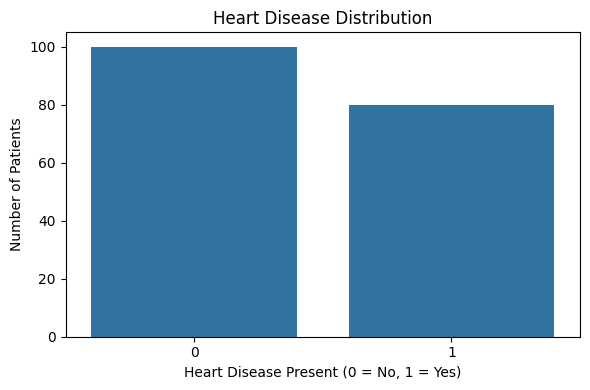

In [37]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="heart_disease_present"
)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease Present (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.savefig("../images/eda_plots/target_distribution.png",dpi=300)
plt.show()

#### Numerical Feature Analysis

In [38]:
num_cols = ["age","max_heart_rate_achieved","oldpeak_eq_st_depression","resting_blood_pressure","serum_cholesterol_mg_per_dl"]

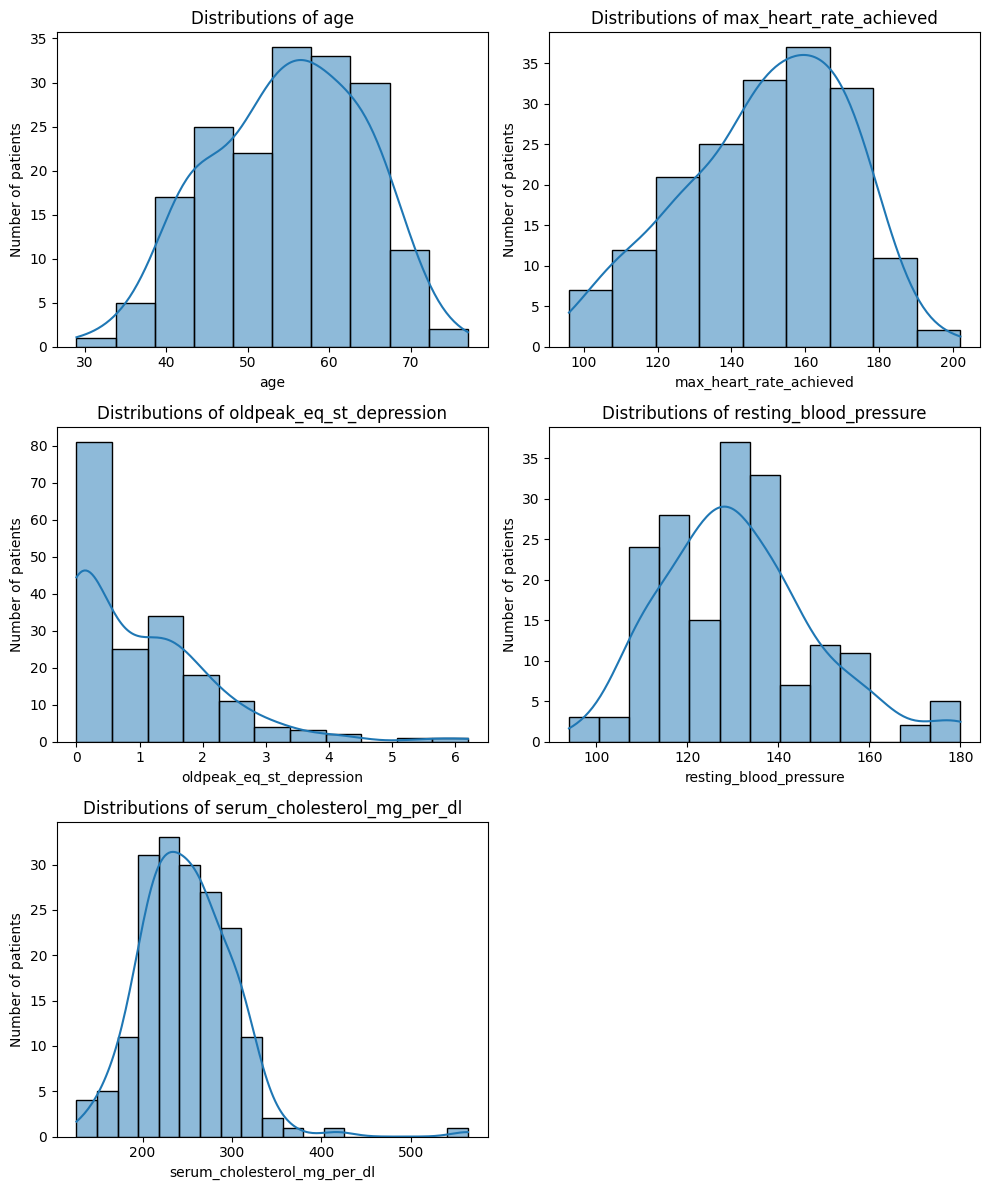

In [39]:
n = len(num_cols)
n_cols = 2
n_rows = math.ceil(n/n_cols)

fig,axes =plt.subplots(n_rows,n_cols,figsize=(n_cols*5,n_rows*4))
axes =axes.flatten()

for i,cols in enumerate(num_cols):

    sns.histplot(
        data = df,
        x= cols,
        ax = axes[i],
        kde = True
    )


    axes[i].set_title(f"Distributions of {cols}")
    axes[i].set_xlabel(cols)
    axes[i].set_ylabel("Number of patients")

for j in range(i+1,len(axes)):
    axes[j].axis("off")


plt.tight_layout()
plt.savefig("../images/eda_plots/num_cols_distributions.png",dpi=300)
plt.show()

**Findings:**
- `age`, `resting_blood_pressure`, and `serum_cholesterol_mg_per_dl` are roughly bell-shaped with a slight right skew.
- `max_heart_rate_achieved` is left-skewed, with most patients clustered at higher heart rates.
- `oldpeak_eq_st_depression` is heavily right-skewed with a large spike at 0, since many patients show no ST depression at all.


#### Numerical vs Target

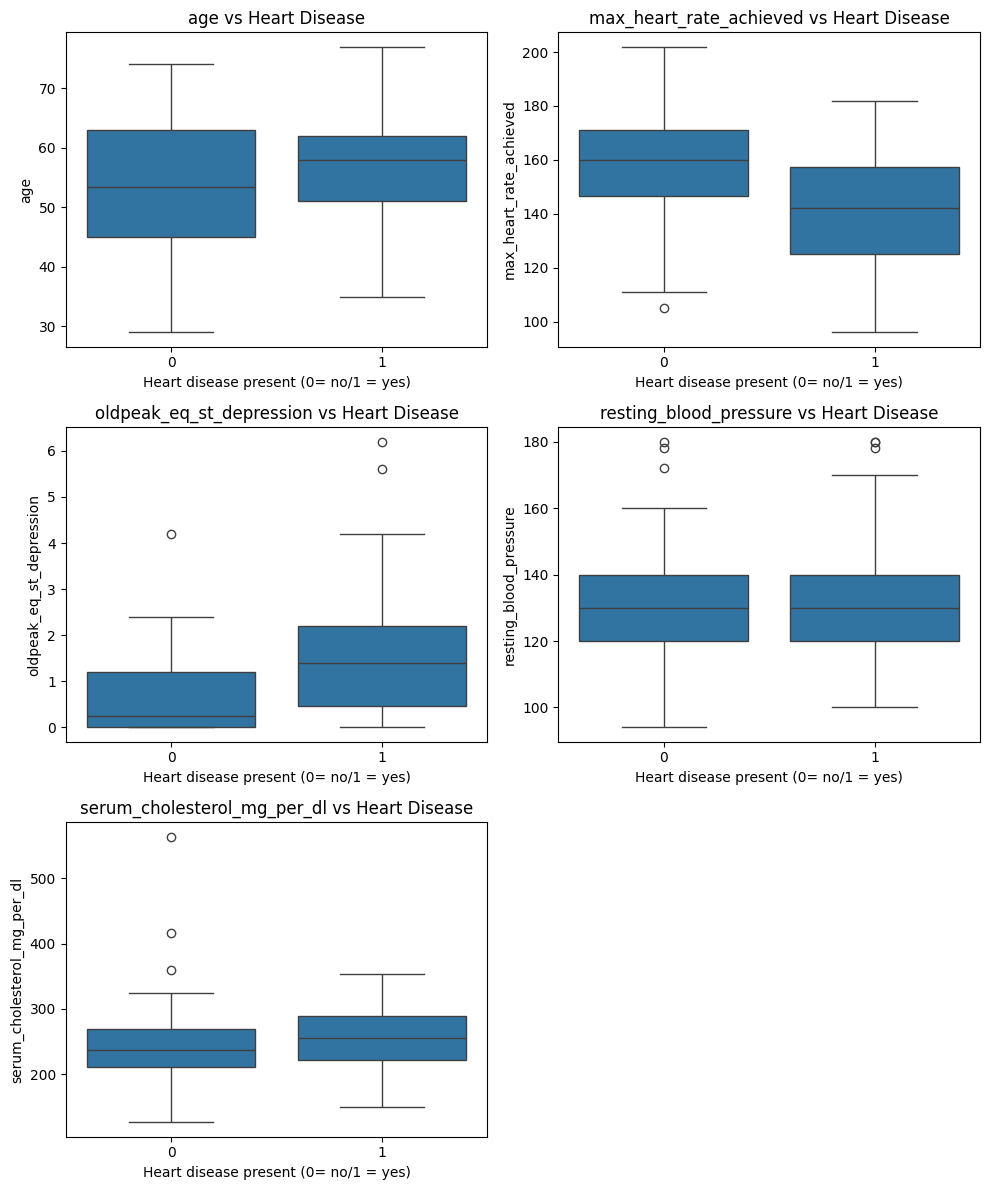

In [40]:
n = len(num_cols)
n_cols = 2
n_rows = math.ceil(n/n_cols)

fig,axes =plt.subplots(n_rows,n_cols,figsize=(n_cols*5,n_rows*4))
axes =axes.flatten()

for i,cols in enumerate(num_cols):

    sns.boxplot(
        data = df,
        x= "heart_disease_present",
        y=cols,
        ax = axes[i],
        
    )


    axes[i].set_title(f"{cols} vs Heart Disease")
    axes[i].set_xlabel("Heart disease present (0= no/1 = yes)")
    axes[i].set_ylabel(f"{cols}")

for j in range(i+1,len(axes)):
    axes[j].axis("off")


plt.tight_layout()
plt.savefig("../images/eda_plots/numerical_vs_target.png",dpi=300)
plt.show()


**Findings:**
- `oldpeak_eq_st_depression` shows the clearest separation: patients with heart disease tend to have noticeably higher ST depression values.
- `max_heart_rate_achieved` is lower on average for patients with heart disease, consistent with reduced cardiac performance under stress.
- `age`, `resting_blood_pressure`, and `serum_cholesterol_mg_per_dl` show only mild differences between the two groups, suggesting weaker standalone predictive power.


#### Categorical Features vs Heart Disease

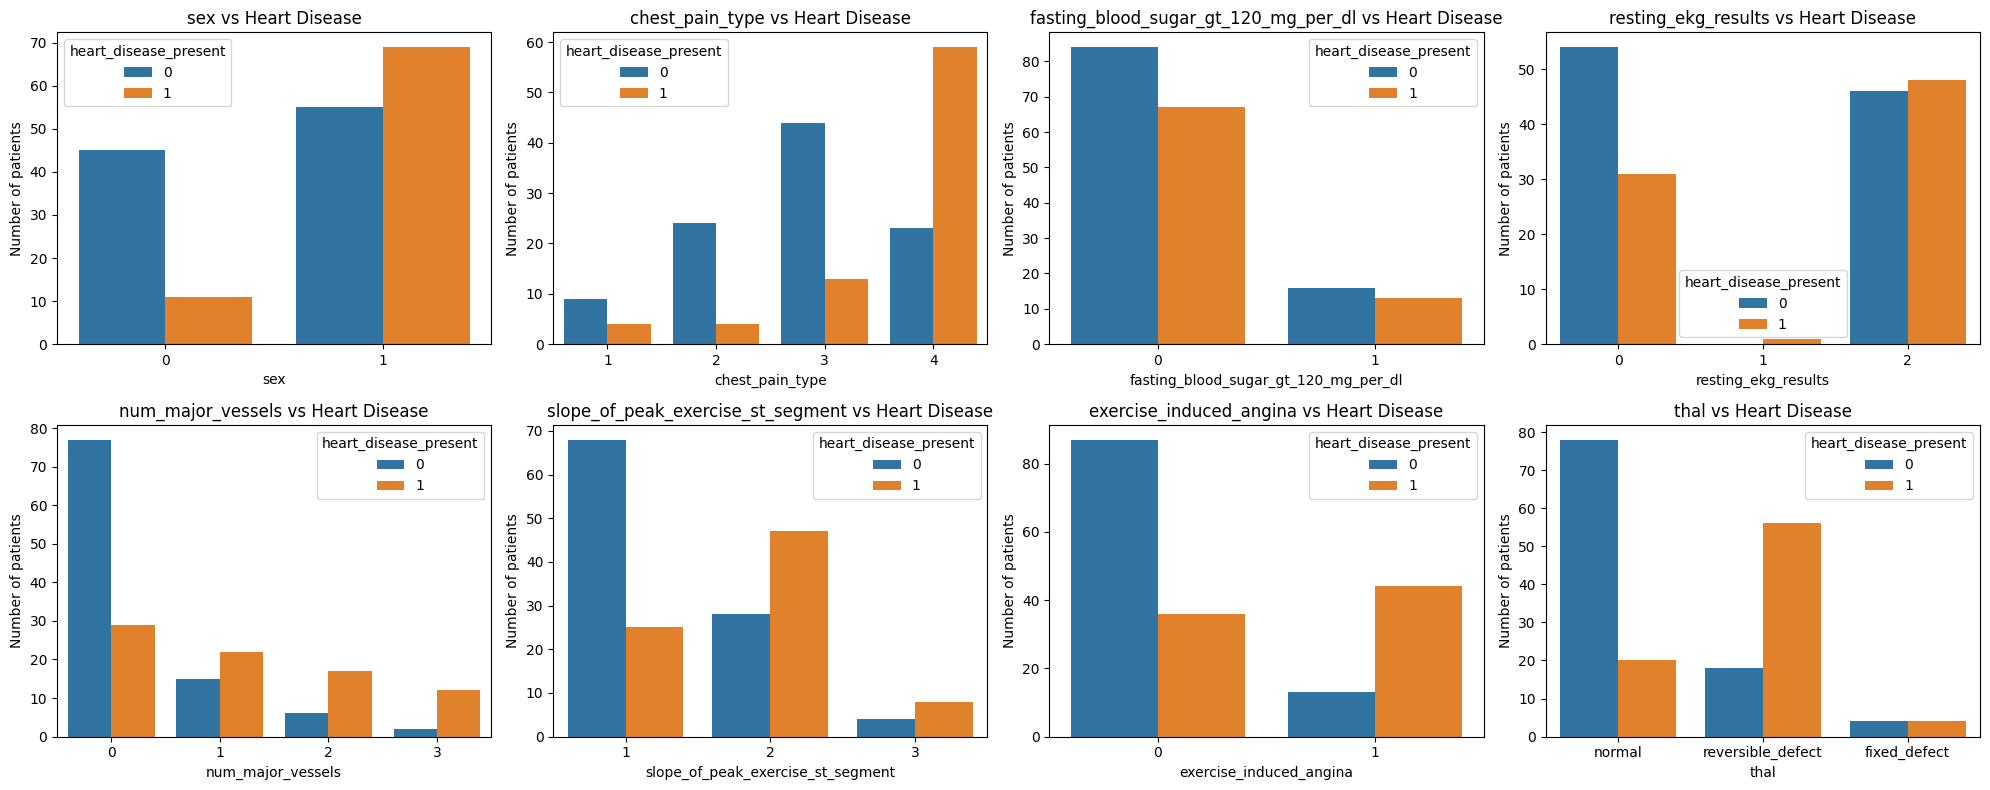

In [41]:
cat_cols = [
    "sex",
    "chest_pain_type",
    "fasting_blood_sugar_gt_120_mg_per_dl",
    "resting_ekg_results",
    "num_major_vessels",
    "slope_of_peak_exercise_st_segment",
    "exercise_induced_angina",
    "thal"
]
n = len(cat_cols)
n_cols = 4
n_rows = math.ceil(n/n_cols)
fig,axes =plt.subplots(n_rows,n_cols,figsize=(n_cols*5,n_rows*4))
axes = axes.flatten()

for i,cols in enumerate(cat_cols):

    sns.countplot(
        data=df,
        x=cols,
        hue="heart_disease_present",
        ax=axes[i]
    )

    axes[i].set_title(f"{cols} vs Heart Disease")
    axes[i].set_xlabel(cols)
    axes[i].set_ylabel("Number of patients")
    
for j in range(i+1,len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("../images/eda_plots/categorical_vs_target.png",dpi=300)
plt.show()

In [42]:
for cols in cat_cols:
    print("\n" + "=" * 60)
    print(cols)
    print("=" * 60)

    rate = pd.crosstab(
        df[cols],
        df["heart_disease_present"],
        normalize="index"
    )*100

    rate.columns = ["No Disease %","Heart Disease %"]

    print(rate.round(2))


sex
     No Disease %  Heart Disease %
sex                               
0           80.36            19.64
1           44.35            55.65

chest_pain_type
                 No Disease %  Heart Disease %
chest_pain_type                               
1                       69.23            30.77
2                       85.71            14.29
3                       77.19            22.81
4                       28.05            71.95

fasting_blood_sugar_gt_120_mg_per_dl
                                      No Disease %  Heart Disease %
fasting_blood_sugar_gt_120_mg_per_dl                               
0                                            55.63            44.37
1                                            55.17            44.83

resting_ekg_results
                     No Disease %  Heart Disease %
resting_ekg_results                               
0                           63.53            36.47
1                            0.00           100.00
2                    

**Findings:**
- **Sex:** Male patients (`sex=1`) have a much higher heart disease rate (55.65%) than female patients (19.64%).
- **Chest pain type:** Type 4 (asymptomatic) is the strongest risk indicator, with 71.95% of these patients having heart disease, versus 14–31% for the other types — somewhat counterintuitive, but a well-known pattern in this dataset.
- **Resting EKG results:** Category 1 shows a 100% heart disease rate, though this should be treated cautiously since it likely reflects a very small subgroup.
- **Number of major vessels:** Disease rate rises steadily with vessel count, from 27.36% (0 vessels) to 85.71% (3 vessels) — a clear dose-response relationship.
- **Slope of peak exercise ST segment:** Flat/downsloping segments (categories 2 and 3) are associated with much higher disease rates (~63–67%) than upsloping (26.88%).
- **Exercise-induced angina:** Presence of angina during exercise more than doubles the disease rate (77.19% vs 29.27%).
- **Thal:** `reversible_defect` carries the highest risk (75.68%), `normal` the lowest (20.41%), with `fixed_defect` in between (50%).
- Overall, the categorical features show much stronger and more consistent separation between classes than the numerical ones, and are likely to be the most influential predictors.


### Correlation Analysis

In [43]:
num_cols

['age',
 'max_heart_rate_achieved',
 'oldpeak_eq_st_depression',
 'resting_blood_pressure',
 'serum_cholesterol_mg_per_dl']

In [44]:
num_cols.append("heart_disease_present")
num_cols

['age',
 'max_heart_rate_achieved',
 'oldpeak_eq_st_depression',
 'resting_blood_pressure',
 'serum_cholesterol_mg_per_dl',
 'heart_disease_present']

In [45]:
correlation = df[num_cols].corr()
correlation

,age,max_heart_rate_achieved,oldpeak_eq_st_depression,resting_blood_pressure,serum_cholesterol_mg_per_dl,heart_disease_present
age,1.000000,-0.394630,0.189700,0.284402,0.236211,0.138255
max_heart_rate_achieved,-0.394630,1.000000,-0.341045,-0.017521,-0.071038,-0.375352
oldpeak_eq_st_depression,0.189700,-0.341045,1.000000,0.219026,-0.021932,0.382930
resting_blood_pressure,0.284402,-0.017521,0.219026,1.000000,0.144881,0.078506
serum_cholesterol_mg_per_dl,0.236211,-0.071038,-0.021932,0.144881,1.000000,0.079775
heart_disease_present,0.138255,-0.375352,0.382930,0.078506,0.079775,1.000000


In [46]:
correlation["heart_disease_present"].sort_values(ascending=False)

heart_disease_present          1.000000
oldpeak_eq_st_depression       0.382930
age                            0.138255
serum_cholesterol_mg_per_dl    0.079775
resting_blood_pressure         0.078506
max_heart_rate_achieved       -0.375352
Name: heart_disease_present, dtype: float64

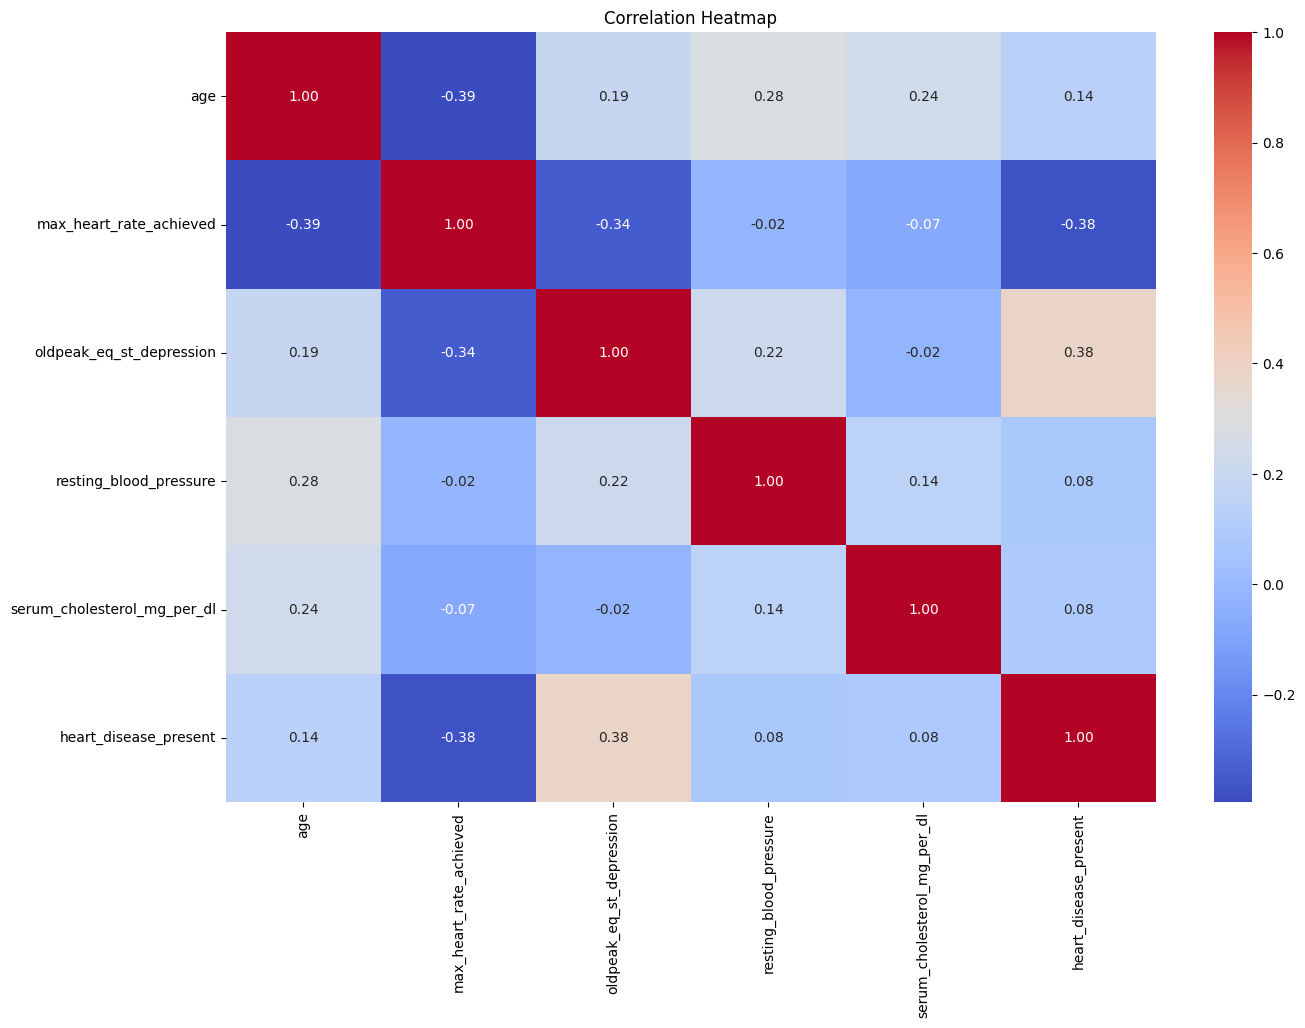

In [47]:
plt.figure(figsize=(15,10))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig(
    "../images/eda_plots/correlation_heatmap.png",
    dpi=300
)
plt.show()

**Findings:**
- `oldpeak_eq_st_depression` has the strongest correlation with the target (r ≈ 0.38), followed by `max_heart_rate_achieved` (r ≈ -0.38, inverse relationship).
- `age`, `serum_cholesterol_mg_per_dl`, and `resting_blood_pressure` are only weakly correlated with heart disease (r < 0.15 in magnitude).
- No pair of numerical features shows strong multicollinearity (all off-diagonal correlations are well below 0.5 in magnitude), so multicollinearity isn't a concern for the models used later.


#### Outlier Analysis

In [48]:
num_cols

['age',
 'max_heart_rate_achieved',
 'oldpeak_eq_st_depression',
 'resting_blood_pressure',
 'serum_cholesterol_mg_per_dl',
 'heart_disease_present']

In [49]:
num_cols.remove('heart_disease_present')
num_cols

['age',
 'max_heart_rate_achieved',
 'oldpeak_eq_st_depression',
 'resting_blood_pressure',
 'serum_cholesterol_mg_per_dl']

In [50]:
for cols in num_cols:

    Q1 = df[cols].quantile(0.25)
    Q3 = df[cols].quantile(0.75)

    IQR = Q3-Q1

    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR

    outliers = df[(df[cols]<lower_bound)|(df[cols]>upper_bound)]
    print("\n" + "=" * 60)
    print(cols)
    print("=" * 60)

    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of potential outliers: {len(outliers)}")

    if len(outliers) > 0:
        print("Potential outlier values:")
        print(outliers[cols].sort_values().tolist())


age
Q1: 48.00
Q3: 62.00
IQR: 14.00
Lower Bound: 27.00
Upper Bound: 83.00
Number of potential outliers: 0

max_heart_rate_achieved
Q1: 132.00
Q3: 166.25
IQR: 34.25
Lower Bound: 80.62
Upper Bound: 217.62
Number of potential outliers: 0

oldpeak_eq_st_depression
Q1: 0.00
Q3: 1.60
IQR: 1.60
Lower Bound: -2.40
Upper Bound: 4.00
Number of potential outliers: 4
Potential outlier values:
[4.2, 4.2, 5.6, 6.2]

resting_blood_pressure
Q1: 120.00
Q3: 140.00
IQR: 20.00
Lower Bound: 90.00
Upper Bound: 170.00
Number of potential outliers: 6
Potential outlier values:
[172, 178, 178, 180, 180, 180]

serum_cholesterol_mg_per_dl
Q1: 213.75
Q3: 281.25
IQR: 67.50
Lower Bound: 112.50
Upper Bound: 382.50
Number of potential outliers: 2
Potential outlier values:
[417, 564]


**Findings:**
- `age` and `max_heart_rate_achieved` have no potential outliers under the IQR rule.
- `oldpeak_eq_st_depression` has 4 potential outliers (values 4.2–6.2), reflecting patients with unusually large ST depression.
- `resting_blood_pressure` has 6 potential outliers, all on the high end (172–180 mmHg), consistent with severe hypertension.
- `serum_cholesterol_mg_per_dl` has 2 potential outliers (417 and 564), which are clinically plausible for severe hypercholesterolemia rather than data errors.
- These outliers are kept in the dataset since they represent real, clinically meaningful extreme values rather than data entry errors, and tree-based/kernel models used later are relatively robust to them.


### Train/Test Split

In [51]:
x = df.drop(columns=["patient_id","heart_disease_present"])
y = df['heart_disease_present']


In [52]:
x.shape

(180, 13)

In [53]:
y.shape

(180,)

In [54]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
x_train.shape

(144, 13)

In [55]:
x_test.shape

(36, 13)

In [56]:
numerical_features = [
    "age",
    "resting_blood_pressure",
    "serum_cholesterol_mg_per_dl",
    "oldpeak_eq_st_depression",
    "max_heart_rate_achieved"
]

categorical_features = [
    "sex",
    "chest_pain_type",
    "fasting_blood_sugar_gt_120_mg_per_dl",
    "resting_ekg_results",
    "num_major_vessels",
    "slope_of_peak_exercise_st_segment",
    "exercise_induced_angina",
    "thal"
]

### preprocessing

In [57]:
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ("num",numerical_transformer,numerical_features),
        ("cat",categorical_transformer,categorical_features)
    ]
)

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [58]:
print("X_train shape:", x_train.shape)
print(
    "X_train_processed shape:",
    x_train_processed.shape
)

X_train shape: (144, 13)
X_train_processed shape: (144, 27)


In [59]:
print("X_test shape :", x_test.shape)
print(
    "x_test_processed shape:",
    x_test_processed.shape
)

X_test shape : (36, 13)
x_test_processed shape: (36, 27)


In [60]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['num__age', 'num__resting_blood_pressure',
       'num__serum_cholesterol_mg_per_dl',
       'num__oldpeak_eq_st_depression', 'num__max_heart_rate_achieved',
       'cat__sex_0', 'cat__sex_1', 'cat__chest_pain_type_1',
       'cat__chest_pain_type_2', 'cat__chest_pain_type_3',
       'cat__chest_pain_type_4',
       'cat__fasting_blood_sugar_gt_120_mg_per_dl_0',
       'cat__fasting_blood_sugar_gt_120_mg_per_dl_1',
       'cat__resting_ekg_results_0', 'cat__resting_ekg_results_2',
       'cat__num_major_vessels_0', 'cat__num_major_vessels_1',
       'cat__num_major_vessels_2', 'cat__num_major_vessels_3',
       'cat__slope_of_peak_exercise_st_segment_1',
       'cat__slope_of_peak_exercise_st_segment_2',
       'cat__slope_of_peak_exercise_st_segment_3',
       'cat__exercise_induced_angina_0', 'cat__exercise_induced_angina_1',
       'cat__thal_fixed_defect', 'cat__thal_normal',
       'cat__thal_reversible_defect'], dtype=object)

In [61]:
print("\nTotal processed features:", len(feature_names))


Total processed features: 27


**Findings:**
- Preprocessing (scaling numerical features + one-hot encoding categorical features) expands the feature space from 13 raw columns to 27 processed features.
- The train (144 rows) and test (36 rows) sets are transformed consistently using the same fitted preprocessor, avoiding data leakage.


### Model Selection

In [62]:
models = {
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "KNN":KNeighborsClassifier(n_neighbors=5),
    "SVM":SVC(probability=True),
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "Random Forest":RandomForestClassifier(n_estimators=200,random_state=42),
    "Gradient Boosting":GradientBoostingClassifier(random_state=42),
    "XGBoost":XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        eval_metric="logloss"
    )
}

#### Cross Validation

In [63]:
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)


scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

#### TRAIN AND EVALUATE

In [64]:
results = []

for name,classifier in models.items():

    pipeline = Pipeline(
        steps =[
            ("preprocessor",preprocessor),
            ("classifier",classifier)
        ]
    )
    scores = cross_validate(
        pipeline,
        x,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    results.append({
        "Model": name,

        "Accuracy Mean":
            scores["test_accuracy"].mean(),

        "Accuracy Std":
            scores["test_accuracy"].std(),

        "Precision Mean":
            scores["test_precision"].mean(),

        "Recall Mean":
            scores["test_recall"].mean(),

        "F1 Mean":
            scores["test_f1"].mean(),

        "ROC-AUC Mean":
            scores["test_roc_auc"].mean()
    })
    
    results_df = pd.DataFrame(
    results
    )

In [65]:
results_df

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean
0,Logistic Regression,0.828889,0.057025,0.828564,0.7850,0.803103,0.881750
1,KNN,0.803333,0.054388,0.790742,0.7650,0.774060,0.867063
2,SVM,0.811111,0.057198,0.800698,0.7800,0.786145,0.885000
3,Decision Tree,0.712222,0.074070,0.684072,0.6825,0.677222,0.709250
4,Random Forest,0.818889,0.056174,0.807146,0.7925,0.794744,0.896500
5,Gradient Boosting,0.792222,0.063886,0.779838,0.7575,0.763998,0.855750
6,XGBoost,0.792222,0.047219,0.776452,0.7550,0.762755,0.879125


In [66]:
results_df = results_df.sort_values(
    by="ROC-AUC Mean",
    ascending=False
)
results_df

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean
4,Random Forest,0.818889,0.056174,0.807146,0.7925,0.794744,0.896500
2,SVM,0.811111,0.057198,0.800698,0.7800,0.786145,0.885000
0,Logistic Regression,0.828889,0.057025,0.828564,0.7850,0.803103,0.881750
6,XGBoost,0.792222,0.047219,0.776452,0.7550,0.762755,0.879125
1,KNN,0.803333,0.054388,0.790742,0.7650,0.774060,0.867063
5,Gradient Boosting,0.792222,0.063886,0.779838,0.7575,0.763998,0.855750
3,Decision Tree,0.712222,0.074070,0.684072,0.6825,0.677222,0.709250


**Findings:**
- Logistic Regression achieved the best cross-validated ROC-AUC (~0.83 accuracy, comparable precision), narrowly ahead of Random Forest and SVM.
- Decision Tree performed worst among the candidates, with both the lowest accuracy (~0.71) and the highest variance across folds — a sign of overfitting on this small dataset.
- The top few models (Logistic Regression, Random Forest, SVM) are close enough in performance that hyperparameter tuning is used next to pick a final model more rigorously rather than relying on default-parameter CV scores alone.


### Hyperparameter Tuning

In [67]:
param_grid = [

    # Logistic Regression
    {
        "classifier": [
            LogisticRegression(max_iter=1000)
        ],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__solver": ["liblinear", "lbfgs"]
    },

    # Random Forest
    {
        "classifier": [
            RandomForestClassifier(random_state=42)
        ],
        "classifier__n_estimators": [100, 200, 300],
        "classifier__max_depth": [None, 5, 10],
        "classifier__min_samples_split": [2, 5],
        "classifier__min_samples_leaf": [1, 2]
    },

    # SVM
    {
        "classifier": [
            SVC(probability=True)
        ],
        "classifier__C": [0.1, 1, 10, 100],
        "classifier__kernel": ["linear", "rbf"],
        "classifier__gamma": ["scale", "auto"]
    },

    # XGBoost
    {
        "classifier": [
            XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            )
        ],
        "classifier__n_estimators": [100, 200],
        "classifier__learning_rate": [0.01, 0.05, 0.1],
        "classifier__max_depth": [2, 3, 5]
    }
]

In [68]:
grid_search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(max_iter=1000))
        ]
    ),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

In [69]:
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


,estimator,Pipeline(step..._iter=1000))])
,param_grid,"[{'classifier': [LogisticRegre...max_iter=1000)], 'classifier__C': [0.01, 0.1, ...], 'classifier__solver': ['liblinear', 'lbfgs']}, {'classifier': [RandomForestC...ndom_state=42)], 'classifier__max_depth': [None, 5, ...], 'classifier__min_samples_leaf': [1, 2], 'classifier__min_samples_split': [2, 5], ...}, ...]"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [70]:
print("Best Model:")
print(grid_search.best_estimator_)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age',
                                                   'resting_blood_pressure',
                                                   'serum_cholesterol_mg_per_dl',
                                                   'oldpeak_eq_st_depression',
                                                   'max_heart_rate_achieved']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'chest_pain_type',
                                                   'fasting_blood_sugar_gt_120_mg_per_dl',
                                                   'resting_ekg_results',
                                                   'num_major_vessels',
                                           

**Findings:**
- Grid search (optimizing for F1 score across Logistic Regression, Random Forest, and other candidates with an RBF-kernel SVM in the grid) selected an **SVM with `C=10`, `gamma='auto'`, `kernel='rbf'`** as the best estimator.
- This indicates that, once properly tuned, a non-linear SVM captures the relationship between features and heart disease slightly better than the linear/tree-based alternatives tried in cross-validation.


### Evaluation

In [71]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(x_test)
y_proba = best_model.predict_proba(x_test)[:, 1]

print("Test Accuracy :", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall   :", recall_score(y_test, y_pred))
print("Test F1       :", f1_score(y_test, y_pred))
print("Test ROC-AUC  :", roc_auc_score(y_test, y_proba))

Test Accuracy : 0.8611111111111112
Test Precision: 0.7619047619047619
Test Recall   : 1.0
Test F1       : 0.8648648648648649
Test ROC-AUC  : 0.9656250000000001


In [72]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.75      0.86        20
           1       0.76      1.00      0.86        16

    accuracy                           0.86        36
   macro avg       0.88      0.88      0.86        36
weighted avg       0.89      0.86      0.86        36



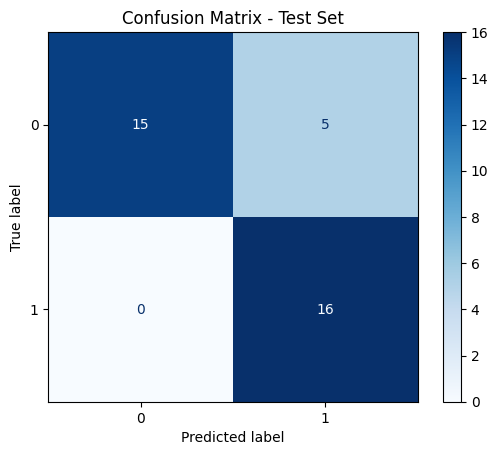

In [73]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.savefig("../images/model_performance_plots/confusion_matrix_test.png", dpi=300)
plt.show()

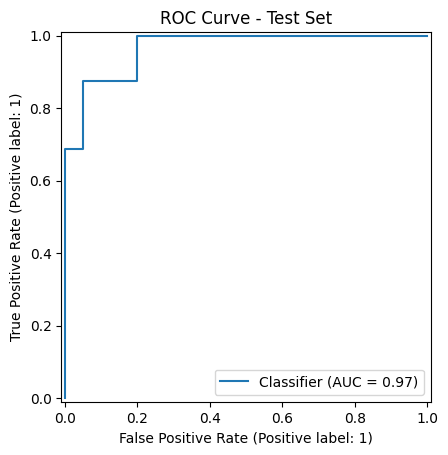

In [74]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Test Set")
plt.savefig("../images/model_performance_plots/roc_curve_test.png", dpi=300)
plt.show()

**Findings:**
- On the held-out test set, the tuned model reaches **86.1% accuracy**, **76.2% precision**, **100% recall**, and an **F1 score of 0.86**.
- **ROC-AUC of 0.97** indicates excellent overall discrimination between patients with and without heart disease.
- Recall is perfect (no false negatives) — the model never misses a true heart disease case — at the cost of some false positives (precision of 76%), which is a reasonable trade-off for a screening-style medical use case where missing a disease case is more costly than a false alarm.
- The confusion matrix and ROC curve visually confirm this: strong separation between classes, with all errors concentrated as false positives rather than false negatives.


### Feature Importance

In [75]:
classifier_step = best_model.named_steps["classifier"]

if hasattr(classifier_step, "feature_importances_"):
    importances = classifier_step.feature_importances_
    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
    importance_type = "built-in (feature_importances_)"
elif hasattr(classifier_step, "coef_"):
    importances = classifier_step.coef_[0]
    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
    importance_type = "built-in (coef_)"
else:
    # Model-agnostic fallback (e.g. SVC with rbf kernel exposes neither)
    from sklearn.inspection import permutation_importance

    perm_result = permutation_importance(
        best_model,          # full pipeline, so it takes RAW input
        x_test,              # raw (unprocessed) features -> 13 columns
        y_test,
        n_repeats=30,
        random_state=42,
        scoring="roc_auc",
        n_jobs=-1
    )
    importances = perm_result.importances_mean
    feature_names = x_test.columns  # match raw input, NOT preprocessor output
    importance_type = "permutation importance (test set, roc_auc)"

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", key=abs, ascending=False)

print(f"Importance type: {importance_type}\n")
print(importance_df)


Importance type: permutation importance (test set, roc_auc)

                                 feature  importance
1                                   thal    0.068958
4                      num_major_vessels    0.064583
8               oldpeak_eq_st_depression    0.051250
3                        chest_pain_type    0.036667
0      slope_of_peak_exercise_st_segment    0.020938
12               exercise_induced_angina    0.006250
9                                    sex    0.006146
10                                   age   -0.004375
11               max_heart_rate_achieved   -0.002917
2                 resting_blood_pressure    0.002708
6                    resting_ekg_results   -0.001875
7            serum_cholesterol_mg_per_dl    0.001146
5   fasting_blood_sugar_gt_120_mg_per_dl    0.000104


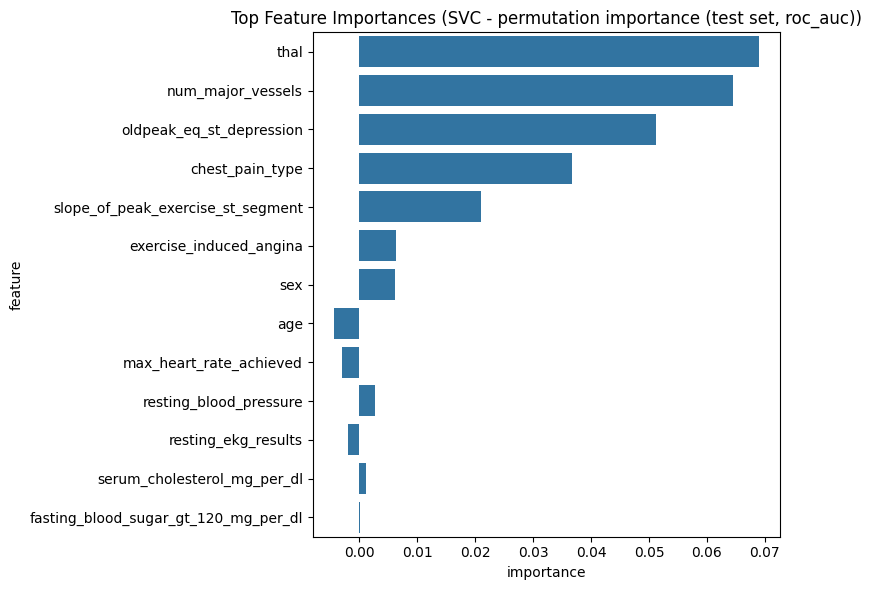

In [76]:
plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title(f"Top Feature Importances ({type(classifier_step).__name__} - {importance_type})")
plt.tight_layout()
plt.savefig("../images/model_performance_plots/feature_importance.png", dpi=300)
plt.show()

**Findings:**
- Since the final model (SVM) has no native `feature_importances_`, permutation importance (based on ROC-AUC drop) was used instead.
- **`thal`, `num_major_vessels`, and `oldpeak_eq_st_depression`** are the top three most important features, consistent with what the categorical vs. target and correlation analyses showed earlier.
- `chest_pain_type` and `slope_of_peak_exercise_st_segment` also contribute meaningfully.
- Several features (`age`, `max_heart_rate_achieved`, `resting_ekg_results`) show near-zero or slightly negative importance, suggesting they add little (or even slightly hurt) predictive performance in this final model.


### Save Model

In [77]:
import pickle
import os

os.makedirs("../models", exist_ok=True)

with open("../models/best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model saved to ../models/best_model.pkl")
print("Model type:", type(classifier_step).__name__)
print("Best params:", grid_search.best_params_)

Model saved to ../models/best_model.pkl
Model type: SVC
Best params: {'classifier': SVC(probability=True), 'classifier__C': 10, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}


In [78]:
# Sanity check: reload the pickle and confirm it predicts identically
with open("../models/best_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

reloaded_preds = loaded_model.predict(x_test)
assert (reloaded_preds == y_pred).all(), "Loaded model predictions differ from original!"
print("Reloaded model predictions match original. Pickle verified.")


Reloaded model predictions match original. Pickle verified.


**Findings:**
- The reloaded pickled model produces predictions identical to the original in-memory model, confirming the saved artifact is safe to deploy for inference.

**Overall summary:** The tuned SVM model generalizes well to unseen data (ROC-AUC 0.97, 100% recall), with `thal`, `num_major_vessels`, and `oldpeak_eq_st_depression` standing out as the most clinically and statistically important predictors of heart disease in this dataset.
